In [1]:
from pathlib import Path
import pandas as pd
from collections import Counter

def nprint(string):
    print("="*25, string, "="*25)

# All the input paths
inspire_path = Path("/home/server/Projects/data/INSPIRE/physionet.org/files/inspire/1.3")
labs_path = inspire_path / "labs.csv"
vitals_path = inspire_path / "vitals.csv"
ops_path = inspire_path / "operations.csv"

preopdata_file = "/home/server/Projects/data/AKI/preop_data.csv"
preopdata_file_andrew = "/home/server/Projects/data/AKI/preop_data_andrew.csv"

nprint("starting")
df_labs = pd.read_csv(labs_path)
df_labs["chart_time"] = df_labs["chart_time"].astype(float)
df_vitals = pd.read_csv(vitals_path)
df_preop = pd.read_csv(preopdata_file)
df_ops = pd.read_csv(ops_path)
nprint("finished reading csvs")

df_preop = df_preop[df_preop["asa"] < 6]
df_preop = df_preop[df_preop["age"] >= 18]
df_preop = df_preop.dropna(subset="opend_time")
df_preop = df_preop.dropna(subset="opstart_time")
df_preop["op_len"] = df_preop["opend_time"] - df_preop["opstart_time"]

# Replace antypes with numbers, after removing rows with regional set as antype
df_ops = df_ops.drop(df_ops[df_ops['antype'] == 'Regional'].index)
df_ops.loc[df_ops['antype'] == 'General', 'antype'] = 0     
df_ops.loc[df_ops['antype'] == 'MAC', 'antype'] = 1
df_ops.loc[df_ops['antype'] == 'Neuraxial', 'antype'] = 1

#don't want to just add encodings to end of dataframe, so insert it where department used to be
col = df_ops.columns.get_loc('department') 
num_cols_added = len(Counter(df_ops['department']))
ops_general = pd.get_dummies(df_ops, columns=['department'])
ops_gen_cols_to_keep = ['op_id', 'subject_id', 'antype']
for column_idx in range(col, col + num_cols_added):
    department_name = ops_general.columns[-1]
    ops_gen_cols_to_keep.append(department_name)
    ops_general.insert(column_idx, department_name, ops_general.pop(department_name))
df_preop = pd.merge(df_preop, ops_general[ops_gen_cols_to_keep], on=['op_id', 'subject_id'], how='inner')

nprint("finished basic filtering")

item_names = [
    "total_protein",
    "sodium",
    "potassium",
    "platelet",
    "glucose",
    "wbc",
    "alt",
    "chloride",
    "lymphocyte",
    "phosphorus",
    "albumin",
    "fibrinogen",
    "creatinine",
    "ptinr",
    "total_bilirubin",
    "alp",
    "aptt",
    "calcium",
    "bun",
    "ast",
    "crp",
    "hb",
    "hct",
    "seg"
]

for item_name in item_names:
    df_preop = pd.merge_asof(df_preop.sort_values('opstart_time'), 
                    df_labs.loc[df_labs['item_name'] == item_name].sort_values('chart_time'), # grab rows w the item name we want and sort by chart_time
                    left_on='opstart_time', right_on='chart_time', by='subject_id',           # chooses row in df_labs w greatest chart_time that is still less than opstart_time and matches subject_id
                    tolerance=90 * 24 * 60, suffixes=('', '_'))                               # 90 day tolerance
    df_preop.drop(columns=['chart_time', 'item_name'], inplace=True)
    df_preop.rename(columns={'value':f'preop_{item_name}'}, inplace=True)


prefixes_to_exclude = ["10", "0TY", "B50", "B51"]
mask = df_ops["icd10_pcs"].astype(str).str.startswith(tuple(prefixes_to_exclude))
ops_to_exclude = df_ops.loc[mask, "op_id"]
df_preop = df_preop[~df_preop["op_id"].isin(ops_to_exclude)]
nprint("finished filtering out some procedure prefixes")



========================= starting =========================
========================= finished reading csvs =========================
========================= finished basic filtering =========================
========================= finished filtering out some procedure prefixes =========================


In [2]:
intraop_csv = '/home/server/Projects/data/AKI/feature_engineered.csv'
df_intraop = pd.read_csv(intraop_csv)

In [6]:
len(df_preop['op_id'].unique())

124294

In [3]:
df_preop

,op_id,subject_id,age,sex,height,weight,asa,emop,opstart_time,opend_time,...,preop_total_bilirubin,preop_alp,preop_aptt,preop_calcium,preop_bun,preop_ast,preop_crp,preop_hb,preop_hct,preop_seg
0,446345798,149047291,60,M,170.0,65.0,4.0,1,20.0,230.0,...,0.5,208.0,31.2,7.5,17.0,35.0,NaN,7.6,22.0,86.8
1,421885878,142440040,35,M,185.0,85.0,2.0,1,45.0,115.0,...,NaN,NaN,30.1,9.4,NaN,NaN,0.02,15.6,46.0,79.9
2,415554065,126841072,55,M,175.0,65.0,2.0,1,45.0,80.0,...,0.5,71.0,28.5,9.1,13.0,31.0,0.02,13.7,40.4,84.2
3,495921883,182581800,55,F,150.0,55.0,2.0,1,50.0,200.0,...,0.7,52.0,32.3,8.7,13.0,22.0,0.06,13.7,42.0,73.7
4,468145039,130014860,45,M,NaN,65.0,1.0,1,50.0,120.0,...,1.9,71.0,34.7,9.1,12.0,31.0,2.25,15.6,46.0,89.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127178,452652040,117366461,70,M,175.0,70.0,2.0,0,5089780.0,5089830.0,...,0.5,80.0,NaN,9.8,18.0,31.0,0.06,15.0,40.4,63.2
127179,481612000,120216423,65,F,150.0,65.0,2.0,0,5114190.0,5114275.0,...,0.5,118.0,30.6,10.0,12.0,20.0,NaN,12.9,39.1,63.2
127180,404672299,185883140,75,M,165.0,70.0,3.0,0,5133165.0,5133565.0,...,0.3,58.0,28.5,8.2,64.0,17.0,22.26,9.1,27.0,75.7
127181,472189264,171991233,35,M,180.0,70.0,1.0,0,5183445.0,5183490.0,...,NaN,42.0,27.9,9.0,12.0,17.0,0.06,15.6,46.0,58.6


In [4]:
df_intraop

,op_id,mean_art_dbp,mean_art_mbp,mean_art_sbp,mean_bt,mean_cpat,mean_cvp,mean_etco2,mean_etgas,mean_fio2,...,sum_ebl,sum_ffp,sum_ftn,sum_n2o,sum_pc,sum_pheresis,sum_rbc,sum_uo,fluids_agg,equiv_MAC_totals
0,400002668,60.952381,82.380952,110.904762,35.516667,NaN,NaN,32.477273,4.645455,52.810000,...,0.250000,NaN,NaN,NaN,NaN,NaN,NaN,1.125000,10.000000,0.733333
1,400004042,48.400000,76.914286,125.342857,33.257895,NaN,7.060606,30.942857,NaN,69.108108,...,0.740741,NaN,NaN,NaN,NaN,NaN,NaN,0.222222,2.962963,NaN
2,400009279,69.257576,86.857143,117.780303,35.696800,35.233083,NaN,33.421642,NaN,55.214286,...,0.186811,NaN,NaN,NaN,NaN,NaN,NaN,1.938161,3.269187,NaN
3,400011247,53.600000,72.571429,114.228571,35.606667,NaN,NaN,32.208333,NaN,NaN,...,1.333333,NaN,NaN,NaN,NaN,NaN,NaN,3.703704,14.814815,NaN
4,400012813,63.942857,75.666667,110.697674,35.615000,32.288889,NaN,29.229167,4.837500,46.372000,...,0.421053,NaN,0.263158,NaN,NaN,NaN,0.0,1.210526,7.368421,1.083333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58584,499993647,52.529412,69.058824,101.588235,35.296875,57.657143,NaN,29.585714,4.337143,35.160000,...,3.333333,NaN,0.333333,NaN,NaN,NaN,NaN,0.533333,17.333333,0.972973
58585,499994225,NaN,NaN,NaN,NaN,NaN,NaN,8.538462,NaN,26.338462,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.132783,NaN
58586,499995750,64.647059,85.764706,114.617647,35.655556,32.914286,2.161290,30.157895,NaN,74.289474,...,0.307692,NaN,NaN,NaN,NaN,NaN,NaN,1.153846,3.846154,NaN
58587,499996674,54.823529,69.555556,104.705882,34.944828,NaN,3.328125,33.628571,NaN,64.223529,...,0.148148,NaN,NaN,NaN,NaN,NaN,NaN,0.740741,1.851852,NaN


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import StandardScaler
import torch
import random
from torch.nn.utils.rnn import pack_padded_sequence
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

def performance_dict(y_binary_test, y_pred, y_prob, bool_print=False, plot=False, copy_print=False):
    rtn = {}
    report = classification_report(y_binary_test, y_pred, output_dict=True)
    rtn['Precision'] = report['True']['precision']
    rtn['Sensitivity'] = report['True']['recall']
    rtn["Accuracy"] = accuracy_score(y_binary_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
    rtn["rc_auc"] = auc(fpr, tpr)
    prec, rec, thresholds = precision_recall_curve(y_binary_test, y_prob)
    rtn["pr_auc"] = auc(rec, prec)
    rtn['Specificity'] = report['False']['recall']
    rtn['Negative Predictive Value'] = report['False']['precision']
    rtn['F1 Score'] = report['True']['f1-score']
    return rtn

def df_to_tensors(df):
    remove_cols = ['op_id', 'time_tensors', 'seq_len', 'aki', 'aki_boolean', 'aki_positive']
    # remove_cols += [col for col in df.columns if '_isna' in col]
    X_tab = torch.tensor(df.drop(columns=remove_cols).values).float()
    X_time = torch.stack(df['time_tensors'].tolist()).float()
    y = torch.tensor(df['aki'].values).unsqueeze(1).float()
    sequence_lengths = df['seq_len'].tolist()
    return X_tab, X_time, y, sequence_lengths

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
df_train_file = '/home/server/Projects/data/AKI/lstm/df_train.pkl'
df_test_file = '/home/server/Projects/data/AKI/lstm/df_test.pkl'
df_train = pd.read_pickle(df_train_file)
df_test = pd.read_pickle(df_test_file)

In [7]:
output_file = '/home/server/Projects/data/AKI/lstm_trainable.csv'
df = pd.read_csv(output_file)

In [8]:
df.shape

(54897, 522)

In [3]:
X_tab_train, X_time_train, y_train, seq_len_train = df_to_tensors(df_train)
X_tab_train = X_tab_train.to(device)
X_time_train = X_time_train.to(device)
y_train = y_train.to(device)

In [4]:
X_tab_test, X_time_test, y_test, seq_len_test = df_to_tensors(df_test)
X_tab_test = X_tab_test.to(device)
X_time_test = X_time_test.to(device)
y_test = y_test.to(device)

In [5]:
def set_seed(seed=42):
    random.seed(seed)                           # Python random module
    np.random.seed(seed)                        # NumPy
    torch.manual_seed(seed)                     # PyTorch CPU
    torch.cuda.manual_seed(seed)                # PyTorch GPU
    torch.cuda.manual_seed_all(seed)            # For multi-GPU setups
    torch.backends.cudnn.deterministic = True   # Makes cuDNN deterministic
    torch.backends.cudnn.benchmark = False      # Avoids dynamic optimizations



class HybridLSTM(nn.Module):
    def __init__(self, num_classes, lstm_width, lstm_hidden, num_layers, tabular_width, mlp_dims=[64, 32, 16]):
        super(HybridLSTM, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.lstm_width = lstm_width #input size
        self.lstm_hidden = lstm_hidden #hidden state
        self.tabular_width = tabular_width
        self.mlp_dims = mlp_dims
        self.fc_interior = (lstm_hidden + mlp_dims[-1]) // 2

        self.mlp = self.build_mlp(tabular_width, mlp_dims)

        self.lstm = nn.LSTM(input_size=lstm_width, hidden_size=lstm_hidden,
                          num_layers=num_layers, batch_first=True) #lstm
        self.fc0 =  nn.Linear(lstm_hidden + mlp_dims[-1], self.fc_interior) #fully connected 1
        self.fc = nn.Linear(self.fc_interior, num_classes) #fully connected last layer


        self.relu = torch.tanh #lol
    # def _init_weights(self):
    #     for name, param in self.lstm.named_parameters():
    #         if 'weight' in name:
    #             nn.init.xavier_uniform_(param)  # Use Xavier initialization
    #         elif 'bias' in name:
    #             nn.init.constant_(param, 0)
    def build_mlp(self, tabular_width, hidden_layer_sizes):
        mlp = nn.Sequential()
        prev = hidden_layer_sizes[0]
        mlp.append(nn.Linear(tabular_width, prev))
        for dim in hidden_layer_sizes[1:]:
                mlp.append(nn.ReLU())
                mlp.append(nn.Linear(prev, dim))
                prev = dim
        # mlp.append(nn.Sigmoid())
        return mlp
    
    def forward(self,tab_x, seq_x, seq_len):
        # h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        # c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        packed_input = pack_padded_sequence(seq_x, seq_len, batch_first=True, enforce_sorted=False)
        output, (hn, cn) = self.lstm(packed_input)#, (h_0, c_0)) #lstm with input, hidden, and internal state
        hn = hn.view(-1, self.lstm_hidden) #reshaping the data for Dense layer next
        lstm_out = self.relu(hn)
        mlp_out = self.mlp(tab_x)

        out = torch.cat((lstm_out, mlp_out), dim=1)
        
        out = self.fc0(out) #first Dense
        out = self.relu(out) #relu
        out = self.fc(out) #Final Output
        return out

In [14]:
del model


# writer = SummaryWriter('/home/server/Projects/data/AKI/runs/hybridlstm_' + 
#                        datetime.now().strftime("%D:%H:%M:%S") + extra_string)

In [6]:
num_epochs = 500 #1000 epochs
learning_rate = 0.001 #0.001 lr

lstm_width = X_time_train.shape[2] # 24 features
mlp_width = X_tab_train.shape[1] # 271 without isna

mlp_dims = [32] #3 layer mlp
lstm_hidden = 8 #number of features in hidden state


num_layers = 1 #number of stacked lstm layers
num_classes = 1 #number of output classes 


batch_size = 5000
num_train_samples = X_tab_train.shape[0]
num_batches = int(np.ceil(num_train_samples / batch_size))

# extra_string = f'isna_hs{lstm_hidden}_m' + "_".join([str(dim) for dim in mlp_dims])
# writer = SummaryWriter('/home/server/Projects/data/AKI/runs/hybridlstm/' + extra_string)

# set_seed(42)

# model = HybridLSTM(num_classes, lstm_width, lstm_hidden, num_layers, mlp_width, mlp_dims).to(device)

In [ ]:

criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 
for epoch in tqdm(range(num_epochs)):
  batch_loss = 0
  for i in range(num_batches):
    beginning_idx = i * batch_size
    ending_idx = min(num_train_samples, (i + 1) * batch_size)
    X_time = X_time_train[beginning_idx: ending_idx]#.to(device)
    X_tab = X_tab_train[beginning_idx: ending_idx]#.to(device)
    y = y_train[beginning_idx: ending_idx]#.to(device)
    seq_len = seq_len_train[beginning_idx: ending_idx]
    outputs = model.forward(X_tab, X_time, seq_len) #forward pass
    
    optimizer.zero_grad() #calculate the gradient, manually setting to 0
    loss = criterion(outputs, y)
    loss.backward() #calculates the loss of the loss function
    optimizer.step() #improve from loss, i.e backprop
    batch_loss += loss.item()

  if epoch % 10 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches))
    writer.add_scalar('training loss',
                          batch_loss / num_batches,
                          epoch * 20 + i)
    if epoch % 30 == 0:
      model.eval()
      with torch.no_grad():
        outputs = model(X_tab_test, X_time_test, seq_len_test)
        leg_y_test = (y_test > 0.3).T.tolist()[0]
        leg_y_pred = (outputs > 0.3).T.tolist()[0]
        leg_y_prob = nn.functional.sigmoid(outputs - 0.3).T.tolist()[0]
        dic = performance_dict(leg_y_test, leg_y_pred, leg_y_prob)
        writer.add_scalar('Precision',
                            dic['Precision'],
                            epoch * num_batches + i)
        writer.add_scalar('Sensitivity',
                            dic['Sensitivity'],
                            epoch * num_batches + i)
        writer.add_scalar('Accuracy',
                            dic['Accuracy'],
                            epoch * num_batches + i)
        writer.add_scalar('rc_auc',
                            dic['rc_auc'],
                            epoch * num_batches + i)
        writer.add_scalar('pr_auc',
                            dic['pr_auc'],
                            epoch * num_batches + i)
        writer.add_scalar('Specificity',
                            dic['Specificity'],
                            epoch * num_batches + i)
        writer.add_scalar('Negative Predictive Value',
                            dic['Negative Predictive Value'],
                            epoch * num_batches + i)
        writer.add_scalar('F1 Score',
                            dic['F1 Score'],
                            epoch * num_batches + i)
      model.train()
print("----------")

  0%|          | 1/500 [00:01<12:08,  1.46s/it]

Epoch: 0, loss: 0.41953


  2%|▏         | 11/500 [00:10<07:13,  1.13it/s]

Epoch: 10, loss: 0.17994


  4%|▍         | 21/500 [00:19<07:07,  1.12it/s]

...

Epoch: 480, loss: 0.01563


 98%|█████████▊| 491/500 [07:17<00:08,  1.12it/s]

Epoch: 490, loss: 0.01550


100%|██████████| 500/500 [07:25<00:00,  1.12it/s]

----------


In [9]:
model.mlp_dims

[64, 32, 16]

In [10]:
model.fc0

Linear(in_features=20, out_features=64, bias=True)

In [ ]:
model.num_classes
model.num_layers
model.lstm_width
model.lstm_hidden
model.tabular_width
model.mlp_dims

In [7]:
# for mlp_dims in [[4, 4], [4, 8, 8], [64, 16, 4], [8, 8, 8], [8, 8, 4, 4], [4, 2, 4], [4, 4, 4, 4], [4, 4, 4]]:
# for mlp_dims in [[4, 4, 2, 2], [16, 16, 16, 16], [4, 4, 8, 2], [4, 4, 4, 2]]:
# for mlp_dims in [[16, 8, 4, 4], [8, 4, 4, 4], [8, 8, 8, 8], [8, 8, 4, 2]]:

mlp_dims = [8, 8, 4, 4]
for lstm_hidden in [2, 4, 8, 16]:
    extra_string = f'isna_hs{lstm_hidden}_m' + "_".join([str(dim) for dim in mlp_dims])
    writer = SummaryWriter('/home/server/Projects/data/AKI/runs/hybridlstm/' + extra_string)

    set_seed(42)

    model = HybridLSTM(num_classes, lstm_width, lstm_hidden, num_layers, mlp_width, mlp_dims).to(device)

    criterion = torch.nn.MSELoss()    # mean-squared error for regression
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 
    for epoch in tqdm(range(num_epochs)):
        batch_loss = 0
        for i in range(num_batches):
            beginning_idx = i * batch_size
            ending_idx = min(num_train_samples, (i + 1) * batch_size)
            X_time = X_time_train[beginning_idx: ending_idx]#.to(device)
            X_tab = X_tab_train[beginning_idx: ending_idx]#.to(device)
            y = y_train[beginning_idx: ending_idx]#.to(device)
            seq_len = seq_len_train[beginning_idx: ending_idx]
            outputs = model.forward(X_tab, X_time, seq_len) #forward pass
            
            optimizer.zero_grad() #calculate the gradient, manually setting to 0
            loss = criterion(outputs, y)
            loss.backward() #calculates the loss of the loss function
            optimizer.step() #improve from loss, i.e backprop
            batch_loss += loss.item()

        if epoch % 10 == 0:
            print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches))
            writer.add_scalar('training loss',
                                batch_loss / num_batches,
                                epoch * num_batches + i)
            if epoch % 30 == 0:
                model.eval()
                with torch.no_grad():
                    outputs = model(X_tab_test, X_time_test, seq_len_test)
                    leg_y_test = (y_test > 0.3).T.tolist()[0]
                    leg_y_pred = (outputs > 0.3).T.tolist()[0]
                    leg_y_prob = nn.functional.sigmoid(outputs - 0.3).T.tolist()[0]
                    dic = performance_dict(leg_y_test, leg_y_pred, leg_y_prob)
                    writer.add_scalar('Precision',
                                        dic['Precision'],
                                        epoch * num_batches + i)
                    writer.add_scalar('Sensitivity',
                                        dic['Sensitivity'],
                                        epoch * num_batches + i)
                    writer.add_scalar('Accuracy',
                                        dic['Accuracy'],
                                        epoch * num_batches + i)
                    writer.add_scalar('rc_auc',
                                        dic['rc_auc'],
                                        epoch * num_batches + i)
                    writer.add_scalar('pr_auc',
                                        dic['pr_auc'],
                                        epoch * num_batches + i)
                    writer.add_scalar('Specificity',
                                        dic['Specificity'],
                                        epoch * num_batches + i)
                    writer.add_scalar('Negative Predictive Value',
                                        dic['Negative Predictive Value'],
                                        epoch * num_batches + i)
                    writer.add_scalar('F1 Score',
                                        dic['F1 Score'],
                                        epoch * num_batches + i)
                model.train()
            print("----------")
    del model

  0%|          | 1/500 [00:01<12:26,  1.50s/it]

Epoch: 0, loss: 0.65816
----------


  2%|▏         | 11/500 [00:11<08:19,  1.02s/it]

Epoch: 10, loss: 0.30179
----------


  4%|▍         | 21/500 [00:21<08:09,  1.02s/it]

...

 96%|█████████▌| 481/500 [08:04<00:19,  1.03s/it]

Epoch: 480, loss: 0.02061
----------


 98%|█████████▊| 491/500 [08:15<00:09,  1.01s/it]

Epoch: 490, loss: 0.02147
----------


100%|██████████| 500/500 [08:24<00:00,  1.01s/it]


----------


In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
print(classification_report(leg_y_test, leg_y_pred))

              precision    recall  f1-score   support

       False       0.95      0.93      0.94      4486
        True       0.24      0.31      0.27       301

    accuracy                           0.89      4787
   macro avg       0.59      0.62      0.60      4787
weighted avg       0.91      0.89      0.90      4787



In [14]:
leg_y_prob

[0.39754241704940796,
 0.3463769853115082,
 0.4188503324985504,
 0.6133655309677124,
 0.4056318998336792,
 0.4683166742324829,
 0.40940821170806885,
 0.4305800199508667,
 0.4135444164276123,
 0.45063942670822144,
 0.396187961101532,
 0.41755032539367676,
 0.410209059715271,
 0.3990084230899811,
 0.42003709077835083,
 0.4113370180130005,
 0.4282706677913666,
 0.3944885730743408,
 0.5046601295471191,
 0.47402286529541016,
 0.8162356615066528,
 0.4136306047439575,
 0.4219425618648529,
 0.426584392786026,
 0.4976349174976349,
 0.47557464241981506,
 0.4135863482952118,
 0.420765221118927,
 0.418411523103714,
 0.4060262143611908,
 0.4384936988353729,
 0.3968631625175476,
 0.4379599988460541,
 0.42963936924934387,
 0.40439459681510925,
 0.43234848976135254,
 0.40711525082588196,
 0.4235181510448456,
 0.4262123703956604,
 0.4124710261821747,
 0.5506315231323242,
 0.39949795603752136,
 0.4136947691440582,
 0.517460286617279,
 0.4368692934513092,
 0.41258126497268677,
 0.4089605212211609,
 0.414

In [46]:
import matplotlib.pyplot as plt

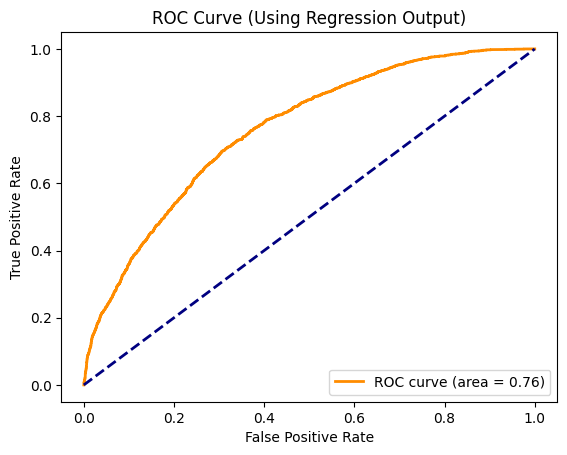

In [47]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {rc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Using Regression Output)')
plt.legend(loc='lower right')
plt.show()